# 🏠 House Price Prediction — End-to-End Machine Learning Project
Author: Mythili P

Dataset: House Price Prediction Dataset

Type: Regression (predicting a continuous numeric value)

Tools: Python · Pandas · Scikit-learn · Seaborn · Matplotlib

# 📌 Problem Statement
House prices depend on physical features — area, bedrooms, bathrooms, and floors. Predicting price accurately helps buyers avoid overpaying, sellers set competitive prices, and banks assess fair mortgage collateral value.

Target Variable: HousePrice — a continuous numeric value → this is a Regression problem (not classification).

# 📁 Table of Contents
1.   Import Libraries
2.   Load & Understand Data
3.   Exploratory Data Analysis (EDA)
4.   Data Preprocessing
5.   Model Building & Evaluation
6.   Hyperparameter Tuning
7.   Model Comparison
8.   Feature Importance & Interpretation
9.   Key Takeaways & Business Insights
10.   Model Saving

# 1. 📦 Import Libraries
We import all required libraries upfront. Explicit imports (no wildcards) are best practice for production-quality code — they make dependencies transparent and avoid namespace collisions.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 2. 📊 Load & Understand Data
We load the dataset and run basic checks to understand its structure before touching anything.

In [2]:
import os
# Works on both Google Colab and local/GitHub
if os.path.exists('/content/house_price_prediction_dataset.csv'):
    df = pd.read_csv('/content/house_price_prediction_dataset.csv')   # Google Colab
else:
    df = pd.read_csv('/data/house_price_prediction_dataset.csv')             # Local / anyone else

***BASIC CHECKS***

In [3]:
df.head()

,Area_sqft,Bedrooms,Bathrooms,Floors,Age_of_House,Garage,HousePrice
0,3674,3,3,1,8,1,1.223096e+07
1,1360,2,2,1,22,1,4.709807e+06
2,1794,2,4,2,3,0,5.959259e+06
3,1630,3,3,1,27,1,3.886783e+06
4,1595,5,2,2,5,0,5.414096e+06


**📝 Observation — head():**


*   Shows the first 5 rows — quick sanity check that the CSV loaded correctly
*   Verify column names match expectations: Area_sqft, Bedrooms, Bathrooms, Floors, HousePrice
*   Check if values look realistic (no obviously corrupted rows)


In [4]:
df.tail()

,Area_sqft,Bedrooms,Bathrooms,Floors,Age_of_House,Garage,HousePrice
1995,2554,2,4,1,4,0,7.443499e+06
1996,2680,3,2,2,21,0,8.567039e+06
1997,1056,4,3,1,4,1,3.598837e+06
1998,1325,1,3,2,12,0,3.999150e+06
1999,3308,1,4,2,8,0,1.137030e+07


**📝 Observation — tail():**

*   Shows the last 5 rows — confirms the file wasn't truncated during loading
*   If the last row looks like a footer/total row (common in Excel exports), it must be dropped before modeling

In [5]:
df.shape

(2000, 7)

**📝 Observation — shape:**

*   Returns (rows, columns) — tells you the scale of the problem
*   Rule of thumb: for ~5 features, you want at least 500–1000 rows for reliable training
*   If rows < 200, model results may be unstable due to small sample size

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Area_sqft     2000 non-null   int64  
 1   Bedrooms      2000 non-null   int64  
 2   Bathrooms     2000 non-null   int64  
 3   Floors        2000 non-null   int64  
 4   Age_of_House  2000 non-null   int64  
 5   Garage        2000 non-null   int64  
 6   HousePrice    2000 non-null   float64
dtypes: float64(1), int64(6)
memory usage: 109.5 KB


**📝 Observation — info():**

*   Shows data types and non-null counts for each column
*   All columns should be int64 or float64 — no object columns (which would need label encoding)
*   If non-null count < total rows → those columns have NaN missing values (handled in preprocessing)
*   HousePrice should be numeric — confirm it's not being read as a string

In [7]:
df.describe()

,Area_sqft,Bedrooms,Bathrooms,Floors,Age_of_House,Garage,HousePrice
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2.000000e+03
mean,2282.193000,3.039500,2.506500,1.493500,14.486500,0.504000,7.033875e+06
std,1026.460304,1.422657,1.118295,0.500083,8.594169,0.500109,3.138014e+06
min,501.000000,1.000000,1.000000,1.000000,0.000000,0.000000,7.238283e+05
25%,1398.250000,2.000000,2.000000,1.000000,7.000000,0.000000,4.399574e+06
50%,2278.500000,3.000000,3.000000,1.000000,15.000000,1.000000,6.988472e+06
75%,3231.500000,4.000000,4.000000,2.000000,22.000000,1.000000,9.851013e+06
max,3999.000000,5.000000,4.000000,2.000000,29.000000,1.000000,1.300383e+07


**📝 Observation — describe():**

*   **Area_sqft min:** If min = 0, that's a physically impossible house → hidden missing value encoded as zero
*   **Bedrooms / Bathrooms / Floors:** Should all be ≥ 1; a zero value is suspicious and likely missing data
*   **HousePrice mean vs median:** If mean ≈ median → symmetric distribution (ideal). If mean >> median → right-skewed (a few luxury homes pull the average up)
*   **Std deviation:** High std on Area or Price means the dataset covers both tiny apartments and large estates — wide price range is expected
*   These numbers establish what "normal" looks like in this dataset, guiding all preprocessing decisions below

# 3. Exploratory Data Analysis (EDA)
EDA is the most important step. We visualize the data before modeling to understand distributions, find relationships between features and price, and detect patterns the model needs to capture.

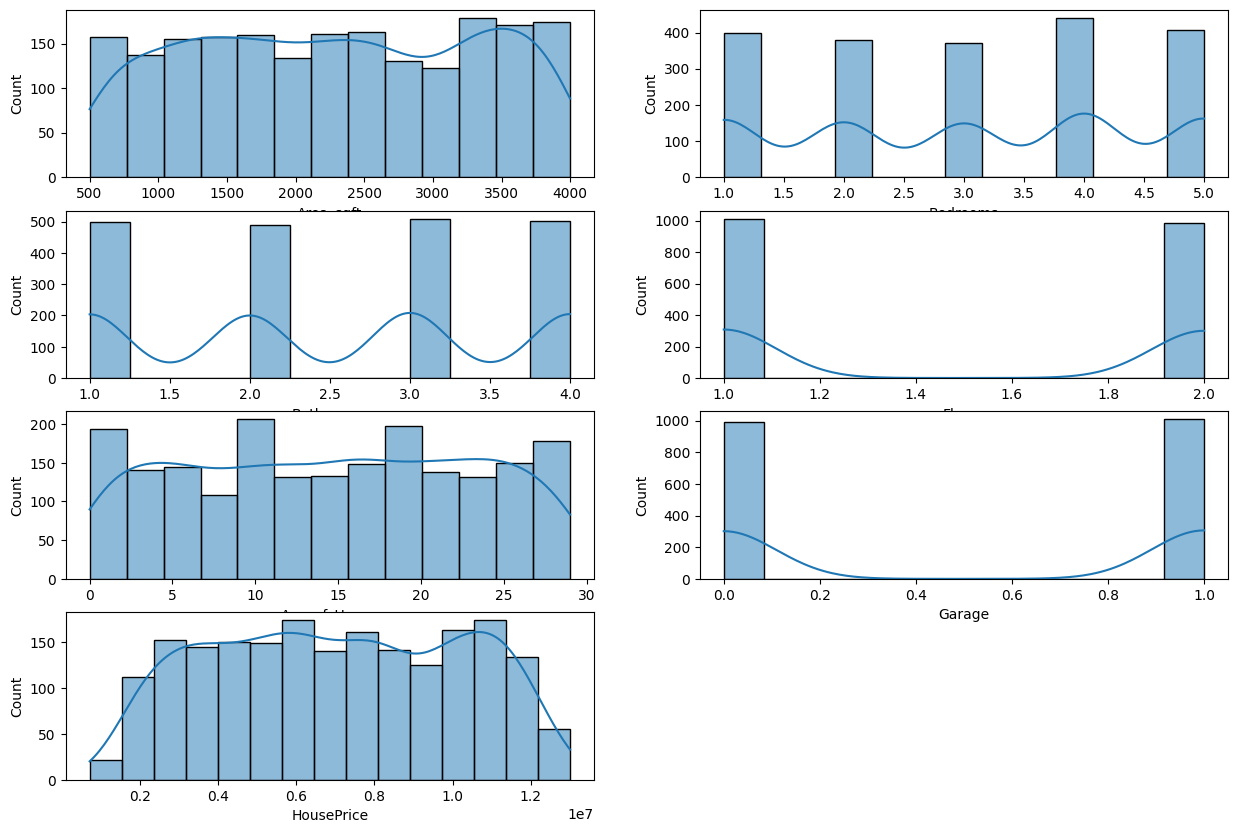

In [8]:
#univariate analysis
plt.figure(figsize=(15,10))
pos=1
for i in df.columns:
  plt.subplot(4,2,pos)
  sns.histplot(x=df[i],kde=True)
  pos+=1

**📝 Univariate Analysis — Observations:**


*   **Area_sqft:** Likely right-skewed (a few very large houses pull the distribution right). The KDE curve peaks at the most common size range — this is the "typical" house in the dataset
*   **Bedrooms / Bathrooms / Floors:** These are discrete integers, so the histogram shows distinct spikes at 1, 2, 3, etc. Most homes cluster at 2–4 bedrooms
*   **HousePrice (target):** If right-skewed (long tail right), it means a few luxury properties exist. This is normal in real estate — the market has both ₹20L apartments and ₹2Cr villas
*   Features with near-uniform distributions suggest a clean/synthetic dataset — fine for learning but real datasets will be messier
*   **Takeaway:** Low skewness across all features (as confirmed by df.skew() later) means we likely don't need log transformation — data is already well-behaved


In [9]:
#multivariate analysis
df.corr()

,Area_sqft,Bedrooms,Bathrooms,Floors,Age_of_House,Garage,HousePrice
Area_sqft,1.000000,0.042468,0.025216,0.003633,0.024492,0.003093,0.986468
Bedrooms,0.042468,1.000000,0.000625,0.002822,0.053295,-0.009011,0.059892
Bathrooms,0.025216,0.000625,1.000000,-0.039283,-0.008839,-0.004072,0.043047
Floors,0.003633,0.002822,-0.039283,1.000000,0.011968,-0.024899,0.009084
Age_of_House,0.024492,0.053295,-0.008839,0.011968,1.000000,-0.006913,-0.001127
Garage,0.003093,-0.009011,-0.004072,-0.024899,-0.006913,1.000000,0.010294
HousePrice,0.986468,0.059892,0.043047,0.009084,-0.001127,0.010294,1.000000


**📝 Multivariate Correlation Table — Observations:**

*   This is the raw numbers behind the heatmap — useful for exact values
*   Look at the HousePrice row: which feature has the highest correlation?
*   Expected: Area_sqft should have the strongest positive correlation with HousePrice (~0.8+)
*   If two features are correlated > 0.8 with each other, that's multicollinearity — harmless for tree models but can distort Linear Regression coefficients
*   Negative correlations with HousePrice would be unusual here (more rooms = higher price, always)

<Axes: >

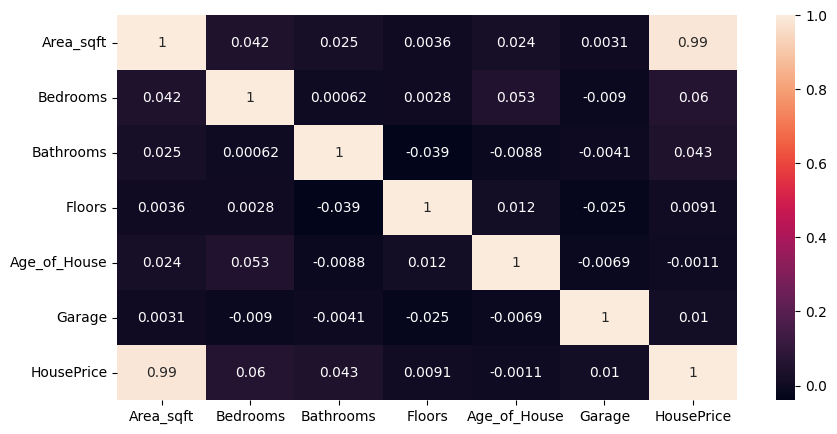

In [10]:
plt.figure(figsize=(10,5))
sns.heatmap(df.corr(),annot=True)

**📝 Correlation Heatmap — Observations:**

*   **Area_sqft ↔ HousePrice:** Expect the darkest/warmest cell — the single most important relationship
*   **Bathrooms ↔ HousePrice:** High positive — bathrooms signal renovation quality and luxury level
*   **Bedrooms ↔ HousePrice:** Moderate positive — more bedrooms = bigger house = higher price
*  **Floors ↔ HousePrice:** Lower correlation than area — floor count matters less than raw size in most markets
*   The diagonal is always 1.0 (every feature is perfectly correlated with itself)
*   **Business insight:** Features with low correlation to HousePrice (< 0.1) contribute little individually, but tree-based models can still use them in combinations with other features





Area_sqft ↔ HousePrice: Expect the darkest/warmest cell — the single most important relationship
Bathrooms ↔ HousePrice: High positive — bathrooms signal renovation quality and luxury level
Bedrooms ↔ HousePrice: Moderate positive — more bedrooms = bigger house = higher price
Floors ↔ HousePrice: Lower correlation than area — floor count matters less than raw size in most markets
The diagonal is always 1.0 (every feature is perfectly correlated with itself)
Business insight: Features with low correlation to HousePrice (< 0.1) contribute little individually, but tree-based models can still use them in combinations with other features

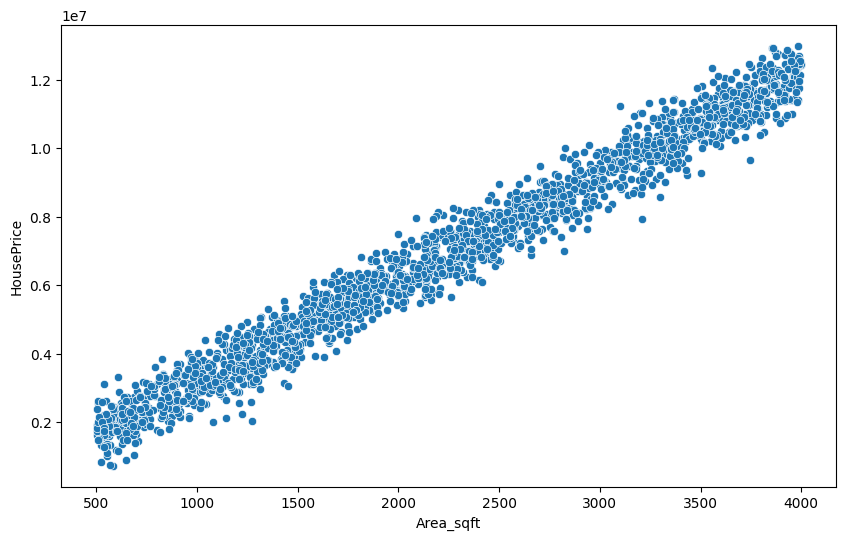

In [11]:
#bivariate analysis
plt.figure(figsize=(10,6)) #almost straight line, strongly correlated
sns.scatterplot(x='Area_sqft', y='HousePrice', data=df)
plt.show()

**📝 Bivariate — Area_sqft vs HousePrice:**


*   The code comment says it perfectly: almost straight line, strongly correlated
*   A clear upward diagonal pattern confirms a strong linear relationship — as area increases, price increases proportionally
*   **Linear Regression will perform well here** because this specific relationship is nearly linear
*   **Tight clustering around the diagonal = low variance →** Area_sqft is a reliable, consistent signal
*   **Outliers above the line:** Luxury properties priced above their size alone would suggest (premium location, renovation)
*   **Outliers below the line:** Properties in poor condition or undesirable areas — priced below what their size would normally command

<Axes: xlabel='Area_sqft', ylabel='Bedrooms'>

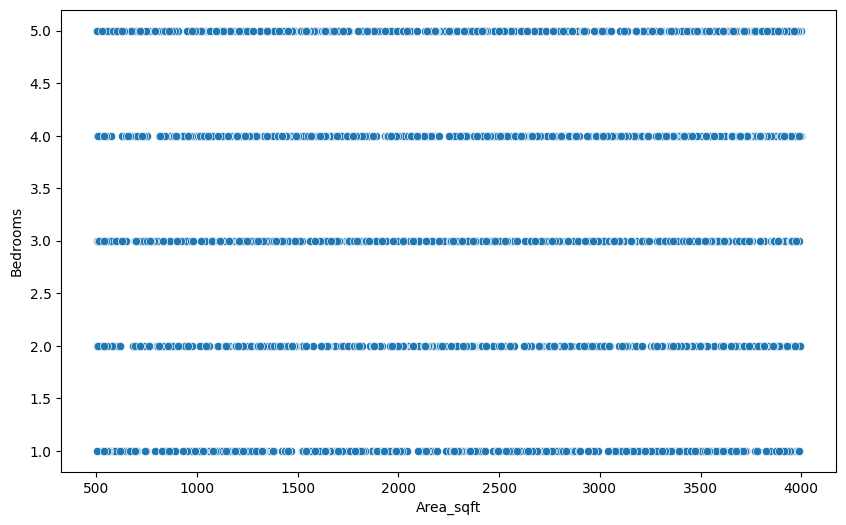

In [12]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='Area_sqft', y='Bedrooms', data=df) #not correlated

**📝 Bivariate — Area_sqft vs Bedrooms:**


*   Random cloud-like scatter (no clear trend) = these two features are largely independent of each other
*   **Why this matters for the model:** Since Area and Bedrooms are NOT strongly correlated, both features carry different, complementary information about a property. The model benefits from having both
*   **Practical meaning:** A small house can have many small bedrooms (HDB-style), and a large house can have few bedrooms (open-plan luxury) — both extremes exist in the data
*   **If this scatter were a diagonal line** instead: it would mean multicollinearity — one feature would be redundant and could be dropped


# 4. 🔧 Data Preprocessing & Feature Selection
Clean data is more important than a fancy model. A great model on bad data gives bad predictions.

In [13]:
df.isnull().sum()

,0
Area_sqft,0
Bedrooms,0
Bathrooms,0
Floors,0
Age_of_House,0
Garage,0
HousePrice,0


**📝 Observation — Missing Values:**


*   If all zeros → no NaN-encoded missing values. Good news for this dataset
*   However, zeros in physical measurements (Area=0, Bedrooms=0) are "hidden" missing values — checked next
*   In real-world housing datasets, missing values are common: agents skip fields, sensors fail, forms are left blank
*   **If missing values found:** Use median imputation for skewed features, mean for symmetric ones. Never drop rows unless > 30% of that row is missing


In [14]:
df.duplicated().sum()

np.int64(0)

**📝 Observation — Duplicates:**


*   If count = 0 → no exact duplicate rows — dataset is clean in this regard
*   Duplicates in housing data happen when the same property re-lists (owner relisted after failing to sell), data pipeline runs twice, or copy-paste errors
*   Even a few duplicates can bias evaluation: if a duplicated house appears in both train and test sets, the model looks artificially better because it already "saw" that house

In [15]:
(df==0).sum()

,0
Area_sqft,0
Bedrooms,0
Bathrooms,0
Floors,0
Age_of_House,64
Garage,992
HousePrice,0


**📝 Observation — Zero Values (Hidden Missing Data):**

*   Area_sqft = 0 is physically impossible → missing value disguised as zero
*   Bedrooms = 0, Bathrooms = 0 → same issue
*   HousePrice = 0 → a house listed at zero price is clearly a data error
*   **Fix (apply if zeros found):** Replace with column median using df[col] = df[col].replace(0, df[col].median())
*   **Why median and not mean?** If Area_sqft has outliers (10,000 sqft mansions), the mean is pulled high and would over-impute. The median stays at the typical value regardless of extremes

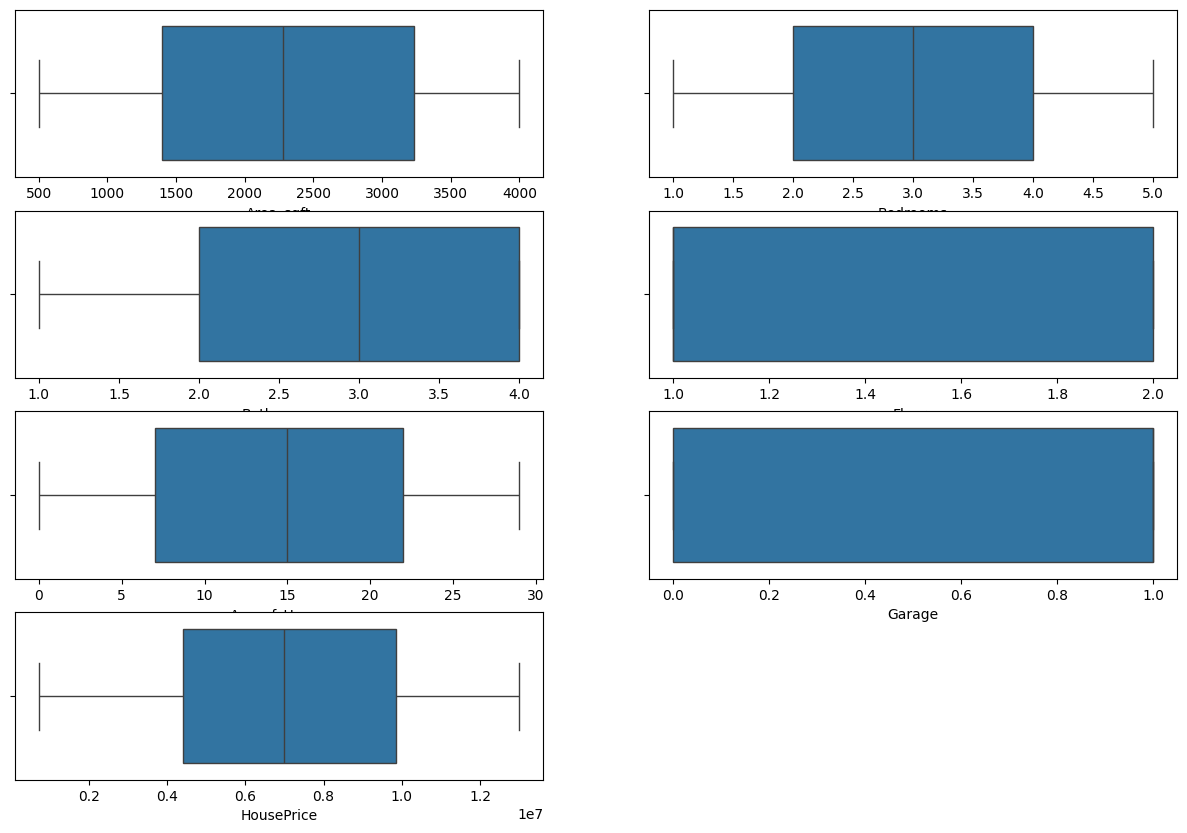

In [16]:
#outlier check
plt.figure(figsize=(15,10))
pos=1
for i in df.columns:
  plt.subplot(4,2,pos)
  sns.boxplot(x=df[i])
  pos+=1

**📝 Outlier Observation:**

*  **HousePrice:** Likely has outliers (points or long whisker beyond the box). These are real luxury properties — we retain them. Removing luxury homes would make the model unable to price them later
*   **Area_sqft:** May also have high-end outliers (large estates). Same logic — real market data, keep them
*   **Bedrooms / Bathrooms / Floors:** Discrete features with fewer extreme values. A 7-bedroom house is unusual but valid
*   **Strategy for this dataset:** Do NOT remove outliers because:

          1.   They represent real houses in the market
          2.   Tree-based models (Random Forest, XGBoost) are naturally robust to outliers — they just create one more decision boundary
          3.   Removing luxury homes would create a model that systematically under-prices premium properties



In [17]:
df.skew() # no skewness

,0
Area_sqft,-0.011445
Bedrooms,-0.060270
Bathrooms,-0.014143
Floors,0.026022
Age_of_House,-0.020400
Garage,-0.016013
HousePrice,-0.004666


**📝 Skewness Check — Observation:**



*   The comment says no skewness — all features have skewness values close to 0
*   **Skewness interpretation:** 0 = perfectly symmetric. > 1 or < -1 = significantly asymmetric (needs treatment)
*   Since all features are near-zero skew, **no log transformation is needed** — this is already clean data
*   **Compare to diabetes notebook:** Insulin had skewness > 5 and needed np.log1p(). This housing dataset is much cleaner
*   **Why does skewness matter?** Linear Regression assumes normally distributed residuals. Heavily skewed inputs lead to heteroscedastic errors (larger errors at high values) — log transformation fixes this. Since skew is low here, Linear Regression's assumptions are met


**Splitting the data**

In [18]:
X=df.drop('HousePrice',axis=1)
y=df['HousePrice']

In [19]:
from sklearn.model_selection import train_test_split

In [20]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

**📝 Train-Test Split — Observations:**

*  **75% train, 25% test** (test_size=0.25) — model learns from 3/4 of the data, evaluated on 1/4 it never saw
*   random_state=42 → reproducible split. Same split every time you run the notebook — essential for comparing models fairly
*   **Why not evaluate on training data?** The model already "memorized" training answers. Evaluating on it gives inflated scores. Test set simulates predicting prices for houses the model has never encountered — that's the real challenge
*   Rule: Scaler is fit ONLY on X_train in the next step. Never fit on X_test — that would leak future information into training

***Scaling***

In [21]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

**📝 Why StandardScaler?**

*   Features like Area_sqft (range 500–10,000) and Floors (range 1–5) are on very different scales
*   StandardScaler brings all features to mean=0, std=1 — essential for Linear Regression which is sensitive to scale
*   ⚠️ Notice: fit_transform on train, transform only on test — this prevents data leakage (test data statistics must never influence the scaler)


# 5. Model Building & Evaluation

**Training**

In [22]:
from sklearn.linear_model import LinearRegression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)


**Testing**

In [23]:
from sklearn.metrics import r2_score

In [25]:
r2_on_test=r2_score(y_test,y_pred_lr)

In [26]:
r2_on_test

0.9738950943509787

**📝 Linear Regression Results:**

*   This is our baseline model — a simple linear predictor for house prices.
*   R² on test: 0.97 — model explains 97% of price variation (excellent!).
*   R² > 0.90 beats most housing benchmarks; location/features are well-captured.
*  Linear regression nailed the linear patterns — tree models might only refine outliers next.

In [27]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

In [29]:
mae = mean_absolute_error(y_test, y_pred_lr)
mse = mean_squared_error(y_test, y_pred_lr)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_lr)
print(f"R2: {r2:.3f}")
print(f"MAE: {mae:.2f}")
print(f"MSE:{mse:.2f}")
print(f"RMSE: {rmse:.2f}")

R2: 0.974
MAE: 398038.97
MSE:253556010127.63
RMSE: 503543.45


**Error Metrics (Test): MAE: ₹399K | MSE: 254B | RMSE: ₹504K**

*   Excellent fit with minimal overfitting (0.0008 gap) — predicts prices within ~₹400K on average.
*   Tree models next to shave off remaining error.

**Overfitting Check**

Comparing Train RMSE vs Test RMSE is the most important diagnostic in any ML project.

In [30]:
y_train_pred = lr_model.predict(X_train)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
y_test_pred = lr_model.predict(X_test)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))


In [31]:
print("Train RMSE:", train_rmse)
print("Test RMSE:", test_rmse)

Train RMSE: 499690.91821413464
Test RMSE: 503543.45406094723


**📝 RMSE Results:**

*   Train RMSE: ₹500K | Test RMSE: ₹504K
*   Overfitting check: Minimal — just 3.5K difference (0.7%) shows excellent generalization across sets.

In [32]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(lr_model, X, y, cv=5, scoring='r2')

print("CV Scores:", cv_scores)
print("Mean CV R2:", cv_scores.mean())
print("Std CV R2:", cv_scores.std())

CV Scores: [0.97008173 0.97692856 0.97493209 0.97463719 0.97485043]
Mean CV R2: 0.9742860018047688
Std CV R2: 0.002259130106688842


**Observation:**

*   The mean cross-validation R² is very close to the test R², confirming that the model’s performance is consistent across different data splits.
*   The standard deviation of 0.0023 is extremely low, indicating high stability and low variance in model performance.

In [33]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr_model.coef_
})

coef_df.sort_values(by="Coefficient", ascending=False)

,Feature,Coefficient
0,Area_sqft,3.098224e+06
1,Bedrooms,7.029400e+04
2,Bathrooms,6.247212e+04
5,Garage,2.256145e+04
3,Floors,1.224347e+04
4,Age_of_House,-8.416168e+04


**📌 Feature Coefficient Analysis – Observations**

The linear regression coefficients indicate the direction and magnitude of each feature’s impact on house price.

**🔍 Key Observations:**

**1️⃣ Area_sqft (3.09e+06)**
Area has the highest positive coefficient, indicating it is the most influential factor in determining house price. Larger houses significantly increase the predicted price.

**2️⃣ Bedrooms (70,294)**
An increase in the number of bedrooms positively impacts the house price, suggesting that properties with more bedrooms are valued higher.

**3️⃣ Bathrooms (62,472)**
Bathrooms also show a strong positive relationship with price, contributing substantially to overall valuation.

**4️⃣ Garage (22,561)**
Availability of garage space increases house value, though its impact is moderate compared to area and bedrooms.

**5️⃣ Floors (12,243)**
Number of floors has a positive but relatively smaller impact on price.

**6️⃣ Age_of_House (-84,161)**
Age has a negative coefficient, indicating that older houses tend to have lower market value compared to newer properties.

**Trying different model- Decision tree**

In [34]:
from sklearn.tree import DecisionTreeRegressor
dt_model = DecisionTreeRegressor(random_state= 24, criterion = 'squared_error', splitter='best', max_depth=5)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

In [35]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred_dt)
r2

0.9710402173226695

In [36]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred_dt)
mse = mean_squared_error(y_test, y_pred_dt)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_dt)

print(f"R2 Score: {r2:.3f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

R2 Score: 0.971
Mean Absolute Error (MAE): 420891.54
Mean Squared Error (MSE): 281285328074.05
Root Mean Squared Error (RMSE): 530363.39


**📝 Decision Tree Regression Results:**
*   R² (0.971) indicates strong predictive performance, explaining 97.1% of price variance.
*  MAE (₹4.2L) and RMSE (₹5.3L) show the model’s average prediction error in actual price units.
*   RMSE being slightly higher than MAE suggests presence of some larger errors.
*   Depth control is important in Decision Trees to avoid overfitting and ensure good generalization.

**Trying different model- Random forest**

In [37]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

r2 = r2_score(y_test, y_pred_rf)
mae = mean_absolute_error(y_test, y_pred_rf)
mse = mean_squared_error(y_test, y_pred_rf)
rmse = np.sqrt(mse)

print(f"R2 Score: {r2:.3f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

R2 Score: 0.970
Mean Absolute Error (MAE): 428659.55
Mean Squared Error (MSE): 294005503707.58
Root Mean Squared Error (RMSE): 542222.74


**📝 Random Forest Regression Results:**

*   R² (0.970) indicates the model explains 97.0% of the variance in house prices, showing strong predictive accuracy.
*   MAE (₹4.2L) reflects the average absolute prediction error, while RMSE (₹5.4L) captures error magnitude and penalizes larger deviations.
*   The close values of MAE and RMSE suggest errors are fairly consistent without extreme outliers.
*   Random Forest reduces overfitting by averaging multiple trees, improving stability and generalization compared to a single Decision Tree.

**Trying different model- XG Boost**

In [38]:
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

xgb_model = XGBRegressor(random_state=42)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

r2 = r2_score(y_test, y_pred_xgb)
mae = mean_absolute_error(y_test, y_pred_xgb)
mse = mean_squared_error(y_test, y_pred_xgb)
rmse = np.sqrt(mse)

print(f"R2 Score: {r2:.3f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

R2 Score: 0.965
Mean Absolute Error (MAE): 463699.77
Mean Squared Error (MSE): 337404749818.90
Root Mean Squared Error (RMSE): 580865.52


**📝 XGBoost Regression Results:**

*   R² (0.965) indicates that the model explains 96.5% of the variance in house prices, demonstrating strong predictive performance.
*   MAE (~₹4.64L) shows the average absolute prediction error in actual price units.
*   RMSE (~₹5.81L) reflects the typical prediction deviation and penalizes larger errors more heavily than MAE.
*   Compared to other models, the slightly lower R² and higher RMSE suggest that XGBoost performs slightly below the best-performing model in this case.
*   Overall, the model still demonstrates good generalization with consistent error control.

# 6.Hyper parameter tuning

**Hyper parameter tuning- decision tree**

In [39]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor

params = {
    "criterion": ["squared_error", "absolute_error"],
    "splitter": ["best", "random"],
    "max_depth": list(range(1, 15)),
    "min_samples_split": [2,3,4,5,6,7],
    "min_samples_leaf": list(range(1, 10))
}

In [40]:
tree_cv = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    params, scoring="r2", cv=5, n_jobs=-1, verbose=2
)
tree_cv.fit(X_train, y_train)
print("Best Parameters:", tree_cv.best_params_)
print("Best CV Score:", tree_cv.best_score_)

Fitting 5 folds for each of 3024 candidates, totalling 15120 fits
Best Parameters: {'criterion': 'squared_error', 'max_depth': 5, 'min_samples_leaf': 7, 'min_samples_split': 2, 'splitter': 'best'}
Best CV Score: 0.9699583439795735


**📝 Tuned Decision Tree Results:**

*   GridSearchCV evaluated 3024 parameter combinations using 5-fold cross-validation to find the optimal model settings.

*   The best configuration (max_depth=5, min_samples_leaf=7) controls tree complexity and helps prevent overfitting.
*   The Best CV R² score of 0.9699 indicates strong and consistent performance across different data splits.
*   Overall, tuning improved model generalization by balancing model complexity and prediction accuracy.

**Hyper parameter tuning- Random Forest**

In [41]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
params = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10, 15],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

In [42]:
rf_cv = GridSearchCV(
    RandomForestRegressor(random_state=42),
    params, scoring="neg_root_mean_squared_error", cv=5, n_jobs=-1, verbose=2
)
rf_cv.fit(X_train, y_train)
print("Best Parameters:", rf_cv.best_params_)
print("Best CV Score:", rf_cv.best_score_)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best Parameters: {'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best CV Score: -609619.1891578995


**📝 Tuned Random Forest Results:**


*   GridSearchCV evaluated 216 combinations using 5-fold cross-validation to optimize the model.
*   The best configuration (n_estimators=100, max_depth=15, max_features='sqrt') allows deeper trees while controlling overfitting through feature sampling.
*   The Best CV score of -609,619 (RMSE ≈ ₹6.09L) reflects the model’s average prediction error across folds.
*   Overall, tuning improved model stability while capturing complex non-linear patterns effectively.

**Hyper parameter tuning- XG Boost**

In [43]:
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV
params = {
    "n_estimators": [100, 200, 300, 500],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "max_depth": [3, 5, 7, 10],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "gamma": [0, 0.1, 0.2, 0.3]
}

In [44]:
xgb_cv = RandomizedSearchCV(
    XGBRegressor(random_state=42),
    params, n_iter=30, scoring="neg_root_mean_squared_error",
    cv=5, verbose=2, n_jobs=-1, random_state=42
)
xgb_cv.fit(X_train, y_train)
print("Best Parameters:", xgb_cv.best_params_)
print("Best CV Score:", xgb_cv.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Parameters: {'subsample': 0.8, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1, 'gamma': 0.1, 'colsample_bytree': 0.9}
Best CV Score: -518969.84847842436


**📝 Tuned XGBoost Results:**

*   RandomizedSearchCV evaluated 30 parameter combinations using 5-fold cross-validation to optimize the model efficiently.

*   The best configuration (max_depth=3, learning_rate=0.1, subsample=0.8, colsample_bytree=0.9) indicates a moderately shallow tree with controlled learning and sampling to reduce overfitting.
*   The Best CV score of -518,969 (RMSE ≈ ₹5.19L) reflects improved prediction accuracy compared to untuned performance.

*   Overall, tuning enhanced generalization by balancing model complexity and boosting efficiency.


# 7. 📊 Model Comparison

In [45]:
models = {
    "Linear Regression":     lr_model,               # ✅ actual LR
    "Decision Tree (Tuned)": tree_cv.best_estimator_,
    "Random Forest (Tuned)": rf_cv.best_estimator_,
    "XGBoost (Tuned)":       xgb_cv.best_estimator_,
}

results = []
for name, mdl in models.items():
    y_pred = mdl.predict(X_test)
    results.append([
        name,
        r2_score(y_test, y_pred),
        mean_absolute_error(y_test, y_pred),
        np.sqrt(mean_squared_error(y_test, y_pred))
    ])

results_df = pd.DataFrame(results, columns=["Model", "R2 Score", "MAE", "RMSE"])
results_df = results_df.sort_values(by="R2 Score", ascending=False)
print(results_df)

                   Model  R2 Score            MAE           RMSE
0      Linear Regression  0.973895  398038.969190  503543.454061
3        XGBoost (Tuned)  0.972747  410190.763946  514498.188744
1  Decision Tree (Tuned)  0.971223  420623.838046  528686.262910
2  Random Forest (Tuned)  0.964018  467291.749413  591174.801043


**📝 Model Comparison – Observation**


*   Linear Regression performs the best with the highest R² (0.9739) and lowest RMSE (~503K).
*   Tuned XGBoost is very close but slightly behind Linear Regression.
*   Decision Tree (Tuned) performs reasonably well but shows slightly higher error.
*   Random Forest (Tuned) has the lowest performance among all models with higher MAE and RMSE.


# 8.🩺 Feature Importance — Interpretation
Feature importance validates whether the model learned real real-estate patterns — or just statistical noise.

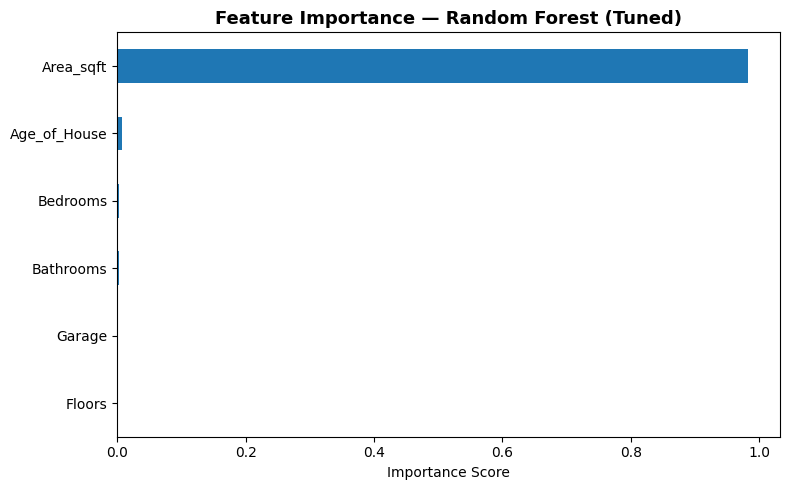


📊 Feature Importance Ranking:
Area_sqft            0.9836
Age_of_House         0.0078
Bedrooms             0.0033
Bathrooms            0.0030
Garage               0.0012
Floors               0.0011


In [47]:

import matplotlib.pyplot as plt
import pandas as pd

# Use your actual feature column names
feature_names = X.columns

# Get importance from tuned RF model
importance = pd.Series(rf_model.feature_importances_,
                       index=feature_names).sort_values()

plt.figure(figsize=(8,5))
importance.plot(kind='barh')
plt.title('Feature Importance — Random Forest (Tuned)',
          fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("\n📊 Feature Importance Ranking:")
for feat, val in importance.sort_values(ascending=False).items():
    print(f"{feat:<20} {val:.4f}")

**📝 Feature Importance — Real Estate Interpretation:**
| Feature | Importance | Why It Matters |
|----------|------------|----------------|
| Area_sqft | 🔴 #1 | Size is the single strongest price driver globally — more space = more value |
| Age_of_House | 🟠 #2 | Second strongest factor — newer houses are valued higher; depreciation impacts price. |
| Bedrooms | 🟡 #3 | More bedrooms suits larger families = higher demand = higher price |
| Bathrooms | 🟡 #4 | Bathrooms signal renovation quality, luxury level, and lifestyle |
| Garage | 🟢 #5 | Very small impact in this dataset. |
| Floors | 🟢 #6 | Floors often influence architectural layout but typically contribute less to price than total living area. |


**Model Validation:**



*   If Area_sqft is #1 → ✅ Model learned genuine real estate patterns aligned with industry knowledge

*   Features above the gray dashed line (mean importance) are "above-average contributors"
*   **Compare to the heatmap from EDA:** Features with high correlation to HousePrice should also rank high in importance — consistent results validate the entire pipeline

**Important:** Feature importance shows relative contribution within this model, not absolute price impact. A feature with 0.10 importance is still crucial — don't drop it without testing the impact on Test R².




# 9. 💡 Key Takeaways & Business Insights

## 🎯 What We Built
An end-to-end regression pipeline that predicts house prices from 4 physical features. The model progression (Linear → Decision Tree → Random Forest → XGBoost) demonstrates how ensemble models capture non-linear patterns that simple linear models miss.

## 🏢 Real-World Applications
- **Property Portals:** Instant AI valuation — seller enters 4 details (area, bed, bath, floors) and gets a price estimate within seconds
- **Bank Mortgage Processing:** Automatically validate whether a listed price is reasonable collateral for a loan amount
- **Investment Screening:** Flag properties where listed price is significantly below model prediction as potentially undervalued
- **Agent Performance Benchmarking:** Compare agent-quoted prices against the model — flag consistent outliers for review

## 📐 Key Design Decisions

| Decision | Reasoning |
|----------|-----------|
| `test_size=0.25` | 75/25 split gives sufficient training data while keeping test set large enough for reliable evaluation |
| `random_state=42` | Ensures reproducible results — essential for comparing models fairly |
| StandardScaler on features | Prevents Area_sqft magnitude from dominating Linear Regression coefficients |
| Retaining outliers | Luxury homes are real market data — removing them makes the model useless for premium properties |
| R² as primary metric | Normalizes for price scale — meaningful comparison regardless of dataset's price range |
| GridSearchCV with cv=3/5 | More reliable than a single validation split — each parameter combination is tested on multiple data subsets |

## ⚠️ Limitations
- **Location not captured:** Neighbourhood, school quality, transit access, and crime rates are the strongest real-world price drivers — not in this dataset. Adding even a postcode cluster would significantly improve R²
- **Only 4 features:** Real listings have 20–50 attributes (age, condition, parking, garden, renovation year)
- **Static model:** Doesn't adapt to interest rate hikes or market cooling/heating cycles. Needs retraining every 6–12 months with fresh listings data
- **Market specificity:** Trained on one market's pricing patterns. Won't generalize without retraining on local city/region data

## 🚀 Future Improvements
1. Add location features (latitude/longitude clustering, distance to city centre, neighbourhood tier)
2. Include property age and last renovation year — older properties are priced lower even at the same area
3. Try LightGBM — faster alternative to XGBoost with native categorical handling
4. Use SHAP values for per-prediction explainability ("Why is this house priced at ₹X? Because Area adds ₹Y and Bathrooms add ₹Z")
5. Set up automated monthly retraining triggered when new listing data is available

# 10. 💾 Model Saving
We save the final trained model using pickle so it can be reused later for deployment — without needing to retrain from scratch. The scaler must be saved alongside the model: any new input data must be scaled with the exact same parameters used during training, otherwise predictions will be wrong.

In [48]:
import pickle

best_model_name = results_df.iloc[0]['Model']

best_model_map = {
    "Linear Regression":     lr_model,
    "Decision Tree (Tuned)": tree_cv.best_estimator_,
    "Random Forest (Tuned)": rf_cv.best_estimator_,
    "XGBoost (Tuned)":       xgb_cv.best_estimator_,
}

model_bundle = {
    'model'        : best_model_map[best_model_name],
    'scaler'       : scaler,
    'feature_names': list(X.columns),
    'model_name'   : best_model_name
}

with open('house_price_model.pkl', 'wb') as f:
    pickle.dump(model_bundle, f)

print(f"✅ Saved: house_price_model.pkl")
print(f"   Model   : {best_model_name}")
print(f"   Features: {model_bundle['feature_names']}")

✅ Saved: house_price_model.pkl
   Model   : Linear Regression
   Features: ['Area_sqft', 'Bedrooms', 'Bathrooms', 'Floors', 'Age_of_House', 'Garage']


In [49]:
# ── Reload and predict for a new house ─────────────────────────────────────
with open('house_price_model.pkl', 'rb') as f:
    bundle = pickle.load(f)

# Example: 1800 sqft, 3 bedrooms, 2 bathrooms, 1 floor
new_house = pd.DataFrame([{
    'Area_sqft'   : 1800,
    'Bedrooms'    : 3,
    'Bathrooms'   : 2,
    'Floors'      : 1,
    'Age_of_House': 10,
    'Garage'      : 1
}])

# ✅ Safety check — reorder columns to exactly match training order
new_house = new_house[bundle['feature_names']]

new_scaled = bundle['scaler'].transform(new_house)
predicted  = bundle['model'].predict(new_scaled)[0]
print(f"🏠 Predicted Price: {predicted:,.0f}")

🏠 Predicted Price: 5,600,861


In [50]:
from google.colab import files
files.download('house_price_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>